In [1]:
import os
from os import walk
from os.path import basename
import re
import bisect
import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import griddata
from scipy import optimize
from scipy.optimize import curve_fit
import imageio
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
#from mpltools import color
import sys
import copy
import cmocean
from PIL import Image

from DSH import SharedFunctions as sf

### Load channel image

(424, 1280)


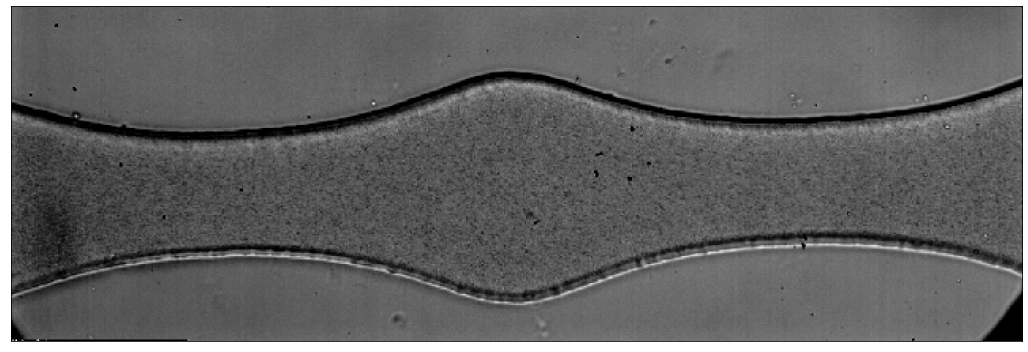

In [2]:
####################
froot = r'C:\Users\steaime\Documents\Research\Rheofluidics\data_for_figs'
fdata_fig1 = os.path.join(froot, 'raw', 'FIG_1')
fdata_fig2 = os.path.join(froot, 'raw', 'FIG_2')
fout_fig1 = os.path.join(froot, 'out')
fout_fig2 = os.path.join(froot, 'out')
img_fname = os.path.join(fdata_fig1,'image_strettoia5.txt')
_img_crop = [15, 30, -30, -60]
_px_size = 0.7 # units: um/px Pixel size is 14x14 um on the detector, objective 20x
_fps = 4051.
_img_cmap = 'Greys_r'
####################

img_arr = np.loadtxt(img_fname)
if (_img_crop[2] <= 0):
    _img_crop[2] = img_arr.shape[1]+_img_crop[2]
if (_img_crop[3] <= 0):
    _img_crop[3] = img_arr.shape[0]+_img_crop[3]
#img_arr_crop = img_arr[_img_crop[1]:_img_crop[1]+_img_crop[3],_img_crop[0]:_img_crop[0]+_img_crop[2]]

fig, ax = plt.subplots(figsize=(20,5))
ax.imshow(img_arr, cmap=_img_cmap, origin='lower')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(fout_fig1, 'FIG1b_channel_strettoia5.tif'))

print(img_arr.shape)

### Load channel edge

(21.0, 254.79999999999998)

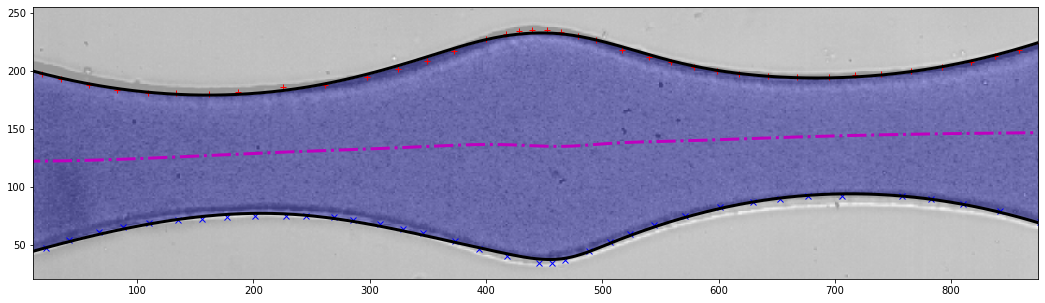

In [22]:
##########
spl_smoothf = 100
##########

edge_x_top, edge_y_top = np.loadtxt(os.path.join(fdata_fig1, 'edge2_fem_um.txt'), unpack=True)
edge_x_bottom, edge_y_bottom = np.loadtxt(os.path.join(fdata_fig1, 'edge1_fem_um.txt'), unpack=True)

###### WARNING: these files were computed with a wrong px->um conversion (1.45 instead of 0.7)
wrong_pxsize = 1.45
print('WARNING: edge data rescaled by a factor {0}/{1}={2:.3f} to correct pixel size conversion'.format(_px_size, wrong_pxsize, _px_size/wrong_pxsize))
edge_x_top *= _px_size/wrong_pxsize
edge_y_top *= _px_size/wrong_pxsize
edge_x_bottom *= _px_size/wrong_pxsize
edge_y_bottom *= _px_size/wrong_pxsize
###########

spl_top = UnivariateSpline(edge_x_top, edge_y_top, s=spl_smoothf)
spl_bottom = UnivariateSpline(edge_x_bottom, edge_y_bottom, s=spl_smoothf)
spl_xarr = np.arange(int(img_arr.shape[1]*_px_size))
ch_center = 0.5*(spl_top(spl_xarr) + spl_bottom(spl_xarr))

fig, ax = plt.subplots(figsize=(20,5))
ax.imshow(img_arr, cmap=_img_cmap, extent=np.multiply(_px_size, [0, img_arr.shape[1], 0, img_arr.shape[0]]), origin='lower')
ax.plot(edge_x_top, edge_y_top, 'r+')
ax.plot(edge_x_bottom, edge_y_bottom, 'bx')

ax.plot(spl_xarr, spl_top(spl_xarr), 'k-', lw=3)
ax.plot(spl_xarr, spl_bottom(spl_xarr), 'k-', lw=3)
ax.plot(spl_xarr, ch_center, 'm-.', lw=3)
ax.fill_between(spl_xarr, spl_top(spl_xarr), spl_bottom(spl_xarr), color=[0.5, 0.5, 1.0], alpha=0.5)
ax.fill_between(spl_xarr, spl_top(spl_xarr), img_arr.shape[0]*_px_size, color='white', alpha=0.6)
ax.fill_between(spl_xarr, spl_bottom(spl_xarr), 0, color='white', alpha=0.6)

ax.set_xlim([_px_size*_img_crop[0],_px_size*_img_crop[2]])
ax.set_ylim([_px_size*_img_crop[1],_px_size*_img_crop[3]])

### Load PIV

(21.0, 254.79999999999998)

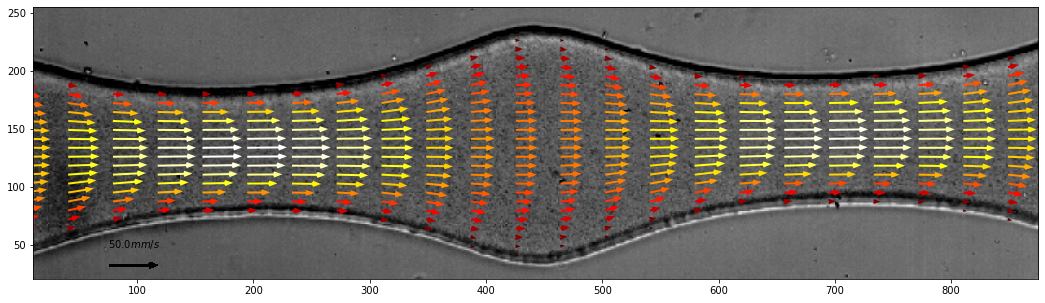

In [4]:
'''
PIV data format:
- space units: px
- speed units: px/frame
- 'v_x.txt','v_y.txt' single component speed in each node of the PIV grid
- 'mesh_x.txt', 'mesh_y.txt' coordinates of the PIV grid nodes
'''
####################
_PIV_fnames = ['v_x.txt','v_y.txt']
_PIV_meshes = ['mesh_x.txt', 'mesh_y.txt']
_quiver_opts = dict(color='k', cmap='hot', units='width', angles='xy', scale=1.2, scale_units='xy', 
                    headlength=4, pivot='tail', width=0.002, headwidth=3, minlength=0)
_quiver_key = [0.1, 0.05, 50.0] # quiverkey [pos_x, pos_y, len] see https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.quiverkey.html
_quiver_keylabel = '{0}'.format(_quiver_key[2]) + r'$mm/s$'
_quiver_keyopts = dict(labelpos='N', coordinates='axes', labelsep=0.2)
_piv_gridsize = 11
_piv_step = [1, 5]
_piv_xyoff = [10,10]
_piv_ctr_left = 
_visc = 0.058 #Pa.s
####################

PIVu, PIVv = [_px_size*_fps*0.001*np.loadtxt(os.path.join(fdata_fig1, fname)) for fname in _PIV_fnames]
PIVx, PIVy = [_px_size*np.loadtxt(os.path.join(fdata_fig1, fname)) for fname in _PIV_meshes]
PIVsext = 0.5 * (np.gradient(PIVu, axis=1)*1.0/(_px_size*_piv_gridsize*1e-3) - np.gradient(PIVv, axis=0)*1.0/(_px_size*_piv_gridsize*1e-3))

fig, ax = plt.subplots(figsize=(20,5))
ax.imshow(img_arr, cmap=_img_cmap, extent=np.multiply(_px_size, [0, img_arr.shape[1], 0, img_arr.shape[0]]), origin='lower')
Q = ax.quiver(PIVx[::_piv_step[0], ::_piv_step[1]], PIVy[::_piv_step[0], ::_piv_step[1]], 
              PIVu[::_piv_step[0], ::_piv_step[1]], PIVv[::_piv_step[0], ::_piv_step[1]], 
              np.hypot(PIVu, PIVv)[::_piv_step[0], ::_piv_step[1]], **_quiver_opts)
if (_quiver_key is not None):
    qk = ax.quiverkey(Q, _quiver_key[0], _quiver_key[1], _quiver_key[2], _quiver_keylabel, **_quiver_keyopts)
ax.set_xlim([_px_size*_img_crop[0],_px_size*_img_crop[2]])
ax.set_ylim([_px_size*_img_crop[1],_px_size*_img_crop[3]])

### Compute planar flow rate and time of transit

Text(0, 0.5, '$q [mm^2/s]$')

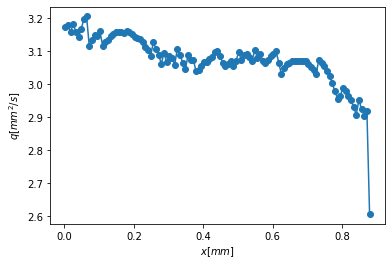

In [5]:
# PIV units: mm/s
planar_flow = np.sum(PIVu, axis=0)*_piv_gridsize*_px_size*1e-3 #units: mm^2/s
PIV_x_mm = PIVx[0]*1e-3

fig, ax = plt.subplots()
ax.plot(PIV_x_mm, planar_flow, 'o-')
ax.set_xlabel(r'$x [mm]$')
ax.set_ylabel(r'$q [mm^2/s]$')

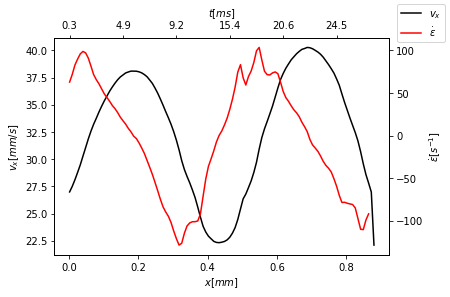

In [24]:
_central_speed = PIVu[(PIVu.shape[0]-1)//2]
_central_stress = PIVsext[(PIVu.shape[0]-1)//2]

PIV_dx = np.zeros_like(PIV_x_mm)
PIV_dx[:-1] = PIV_x_mm[1:]-PIV_x_mm[:-1]
transit_dt = PIV_dx/_central_speed #old version: _piv_gridsize*_px_size*1e-3/_central_speed
transit_time = np.zeros_like(transit_dt)
for i in range(len(transit_dt)):
    transit_time[i] = np.sum(transit_dt[:i])
fig, ax = plt.subplots()
ax.plot(PIV_x_mm, _central_speed, 'k-', label=r'$v_x$')
ax.set_xlabel(r'$x [mm]$')
ax.set_ylabel(r'$v_x [mm/s]$')
ax2 = ax.twinx()
ax2.plot(PIV_x_mm[:-2], _central_stress[:-2], 'r-', label=r'$\dot\varepsilon$')
ax2.set_ylabel(r'$\dot\varepsilon [s^{-1}]$')
#ax2.set_yscale('log')
ax3 = ax.twiny()
t_ticks_loc = PIV_x_mm[::20]
t_ticks_lbl = ['{0:.1f}'.format(1e3*transit_time[bisect.bisect(PIV_x_mm, xloc)]) for xloc in t_ticks_loc]
ax3.set_xticks(t_ticks_loc)
ax3.set_xticklabels(t_ticks_lbl)
ax3.set_xlim(ax.get_xlim())
ax3.set_xlabel(r'$t [ms]$')
fig.legend()

np.savetxt(os.path.join(fout_fig1, 'PIV_postproc_v4.txt'), np.asarray([PIV_x_mm, PIV_dx, _central_speed, transit_dt, 
                                                                       transit_time, planar_flow, _central_stress]).T, 
          delimiter='\t', header='x[mm]\tdx[mm]\tvx_center[mm/s]\tdt=dx/vx[s]\tintegrated_time[s]\tq[mm2/s]\textrate[1/s]')

constriction size: 100.0 microns
maximum channel width: 194.8 microns
average planar flow rate: 4.2 mm2/s
estimate of volumetric flow rate: 0.7 ml/h


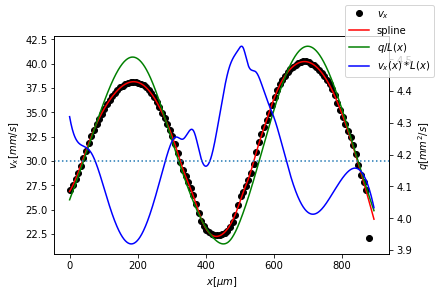

In [7]:
ch_thick = (spl_top(spl_xarr) - spl_bottom(spl_xarr))*1e-6 #units: m
print('constriction size: {0:.1f} microns'.format(np.min(ch_thick)*1e6))
print('maximum channel width: {0:.1f} microns'.format(np.max(ch_thick)*1e6))
spl_ux = UnivariateSpline(PIV_x_mm[:-1]*1e3, _central_speed[:-1], s=1)


integral_q = np.mean(planar_flow[:-1])*1e-6 #units: m2/s
avg_q = np.mean(spl_ux(spl_xarr)*ch_thick*1e3)*1e-6 #units: m2/s
print('average planar flow rate: {0:.1f} mm2/s'.format(avg_q*1e6))
print('estimate of volumetric flow rate: {0:.1f} ml/h'.format(integral_q*6e-5*1e6*3600))

dt_fine = (spl_xarr[1:]-spl_xarr[:-1])*1e-3/spl_ux(spl_xarr[1:])
tx_fine = np.zeros_like(dt_fine)
for i in range(len(dt_fine)):
    tx_fine[i] = np.sum(dt_fine[:i])
    
fig, ax = plt.subplots()
ax.plot(PIV_x_mm*1e3, _central_speed, 'ko', label=r'$v_x$')
plt.plot(spl_xarr, spl_ux(spl_xarr), 'r-', label='spline')
plt.plot(spl_xarr, avg_q*1e6/(ch_thick*1e3), 'g-', label=r'$q/L(x)$')
ax.set_xlabel(r'$x [\mu m]$')
ax.set_ylabel(r'$v_x [mm/s]$')
ax2 = ax.twinx()
ax2.plot(spl_xarr, spl_ux(spl_xarr)*ch_thick*1e3, 'b-', label=r'$v_x(x)*L(x)$')
ax2.axhline(avg_q*1e6, ls=':')
ax2.set_ylabel(r'$q [mm^2/s]$')
#ax2.set_yscale('log')
fig.legend()

Sinusoidal fit of stress profile: amplitude=6.84 Pa, frequency=369.2 rad/s, phi=-2.04 rad


Text(0.5, 0, '$t$ [s]')

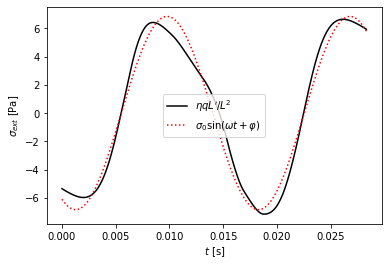

In [8]:
def sinstress(t, A, w, phi):
    return A * np.sin(w * t + phi)
def fit_sinstress(t_data, s_data):
    return curve_fit(sinstress, t_data, s_data, p0=[0.5*(np.max(s_data)-np.min(s_data)), 2*np.pi/np.max(t_data), 0])

ch_th_grad = np.gradient(ch_thick, spl_xarr*1e-6) #unitless
ch_ext_stress = avg_q * _visc * ch_th_grad / np.square(ch_thick)
sinp, cov = fit_sinstress(tx_fine, ch_ext_stress[1:])
print('Sinusoidal fit of stress profile: amplitude={0:.2f} Pa, frequency={1:.1f} rad/s, phi={2:.2f} rad'.format(*sinp))

fig, ax = plt.subplots()
ax.plot(tx_fine, ch_ext_stress[1:], 'k-', label=r'$\eta q L^\prime/L^2$')
ax.plot(tx_fine, sinstress(tx_fine, *sinp), 'r:', label=r'$\sigma_0 \sin(\omega t+\varphi)$')
ax.legend()
ax.set_ylabel(r'$\sigma_{ext}$ [Pa]')
ax.set_xlabel(r'$t$ [s]')

### Compute extensional stress

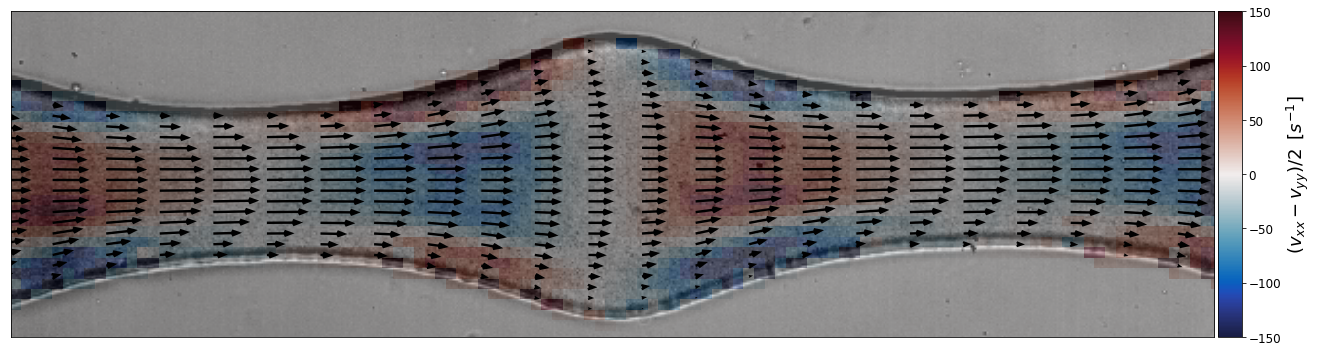

In [9]:
####################
_overlay_type = 'extstress'
_overlay_clip = [-150, 150]
_overlay_cmap = cmocean.cm.balance
_overlay_alpha_pwr = 0
_overlay_alpha_clip = [0, 0.3]
_stream_plot = False
_stream_color = 'norm'
_stream_opts = dict(density=[1,0.6], linewidth=2.0, color='r', cmap='hot', arrowsize=1.0, minlength=0.04)
####################

def get_overlay():
    if (_overlay_type == 'norm'):
        overlay_plot = np.hypot(PIVu, PIVv)
    elif (_overlay_type == 'u'):
        overlay_plot = PIVu
    elif (_overlay_type == 'v'):
        overlay_plot = PIVv
    elif (_overlay_type == 'ux'):
        overlay_plot = np.clip(np.gradient(PIVu, _px_size*_piv_gridsize, axis=1), _overlay_clip[0], _overlay_clip[1])
    elif (_overlay_type == 'vy'):
        overlay_plot = np.clip(np.gradient(PIVv, _px_size*_piv_gridsize, axis=0), _overlay_clip[0], _overlay_clip[1])
    elif (_overlay_type == 'extstress'):
        overlay_plot = np.clip(0.5 * (np.gradient(PIVu, axis=1)*1.0/(_px_size*_piv_gridsize*1e-3) - 
                               np.gradient(PIVv, axis=0)*1.0/(_px_size*_piv_gridsize*1e-3)), _overlay_clip[0], _overlay_clip[1])
        # NOTE: the 1e-3 factor is to convert _px_size from microns to mm (PIV units: mm/s)
    else:
        overlay_plot = None
    colors = None
    if (overlay_plot is not None):
        if type(_overlay_cmap) is str:
            my_cmap = plt.cm.get_cmap(_overlay_cmap)
        else:
            my_cmap = _overlay_cmap
        if _overlay_alpha_pwr != 0:
            alphas = Normalize(clip=True)(np.power(np.nan_to_num(overlay_plot), _overlay_alpha_pwr))  # Create an alpha channel based on weight values. 
        else:
            alphas = np.ones_like(overlay_plot)
        if (_overlay_alpha_clip is not None):
            alphas = np.clip(alphas,_overlay_alpha_clip[0], _overlay_alpha_clip[1])  # alpha value clipped
        colors = Normalize(vmin=np.nanmin(overlay_plot), vmax=np.nanmax(overlay_plot))(overlay_plot) # Normalize the colors b/w 0 and 1, we'll then pass an MxNx4 array to imshow
        colors = my_cmap(colors)
        colors[..., -1] = alphas   # Now set the alpha channel to the one we created above
    return colors
        
if (_stream_color == 'norm'):
    _stream_opts['color'] = np.hypot(PIVu, PIVv)

fig, ax = plt.subplots(figsize=(20,5))
ax.imshow(img_arr, cmap=_img_cmap, extent=np.multiply(_px_size, [0, img_arr.shape[1], 0, img_arr.shape[0]]), origin='lower')
overlay = get_overlay()
if (overlay is not None):
    ovr = ax.imshow(overlay, extent=[np.min(PIVx),np.max(PIVx),np.min(PIVy),np.max(PIVy)], cmap=_overlay_cmap,
                    vmin=_overlay_clip[0], vmax=_overlay_clip[1], origin='lower')
    divider = make_axes_locatable(ax)
    cax_inset = divider.append_axes('right', size='2%', pad=0.05)
    cbar_inset = fig.colorbar(ovr, cax=cax_inset)
    cbar_inset.set_label(r'$(v_{xx}-v_{yy})/2$  $[s^{-1}]$', color='k', rotation=90)#, labelpad=-20)
    #cbar_inset.ax.yaxis.set_label_coords(_img_cax_labelpos[0], _img_cax_labelpos[1])
    cbar_inset.ax.tick_params(labelsize=12)
    #cbar_inset.ax.locator_params(nbins=5)
    cbar_font = matplotlib.font_manager.FontProperties(size=15)
    ax_lbl_font = matplotlib.font_manager.FontProperties()
    ax_lbl_font.set_family('serif')
    ax_lbl_font.set_name('Times New Roman')
    #ax_lbl_font.set_style('italic')
    ax_lbl_font.set_size(18)
    cbar_inset.ax.yaxis.label.set_font_properties(ax_lbl_font)
    cbar_inset.ax.yaxis.set_tick_params(color='k')
    cbar_inset.outline.set_edgecolor('k')
    plt.setp(plt.getp(cbar_inset.ax.axes, 'yticklabels'), color='k')
    
if _stream_plot:
    ax.streamplot(PIVx[0], PIVy[:,0], PIVu, PIVv, **_stream_opts)
else:
    Q = ax.quiver(PIVx[::_piv_step[0], ::_piv_step[1]], PIVy[::_piv_step[0], ::_piv_step[1]], 
                  PIVu[::_piv_step[0], ::_piv_step[1]], PIVv[::_piv_step[0], ::_piv_step[1]], **_quiver_opts)

ax.set_xlim([_px_size*_img_crop[0],_px_size*_img_crop[2]])
ax.set_ylim([_px_size*_img_crop[1],_px_size*_img_crop[3]])

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(fout_fig1, 'FIG1b_lowqk_noqklabel.png'), dpi=300, transparent=True)

### Load FEM simulations

C:\Users\steaime\Documents\Research\Rheofluidics\data_for_figs\out\fem_results_v2_sigmaext.txt saved


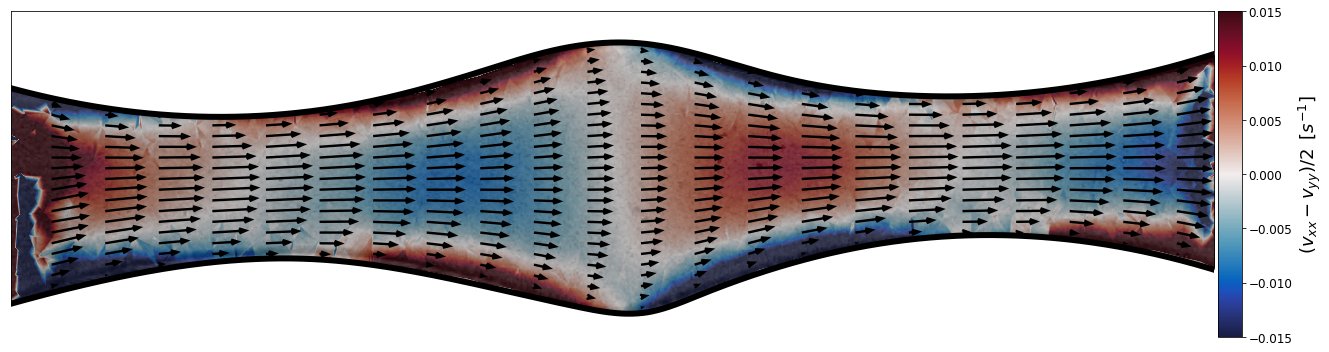

In [12]:
#####################
_fem_fname = os.path.join(fdata_fig1, 'fem_results_v2.txt')
_fem_offset = 40
_fem_uscale = 0.5
_overlay_fem_clip = [-0.015, 0.015]
_overlay_fem_type = 'extstress'
_overlay_fem_cmap = cmocean.cm.balance
_overlay_fem_alpha_pwr = 0
_overlay_fem_alpha_clip = [0, 0.6]
_fem_quiver_step = [11, 55]
_fem_quiver_phase = [1, 2]
_fem_quiver_opts = dict(color='k', cmap='hot', units='width', angles='xy', scale=0.1, scale_units='xy', 
                    headlength=4, pivot='tail', width=0.002, headwidth=3, minlength=0)
#####################

fem_data = np.loadtxt(_fem_fname)
fem_x_px = list(range(img_arr.shape[1]))
fem_y_px = list(range(img_arr.shape[0]))
fem_x, fem_y = np.meshgrid(np.multiply(_px_size, fem_x_px), np.multiply(_px_size, fem_y_px))
fem_u = np.zeros((len(fem_y_px), len(fem_x_px), 3))
for i in range(fem_data.shape[0]):
    xidx = fem_x_px.index(fem_data[i, 1])
    yidx = fem_y_px.index(fem_data[i, 0])
    fem_u[yidx+_fem_offset, xidx, 0] = fem_data[i, 4]
    fem_u[yidx+_fem_offset, xidx, 1] = fem_data[i, 3]
    fem_u[yidx+_fem_offset, xidx, 2] = fem_data[i, 5]
fem_u *= _fem_uscale
fem_uxx = np.gradient(fem_u[:,:,0], _px_size, axis=1)
fem_uyy = np.gradient(fem_u[:,:,1], _px_size, axis=0)
fem_sigmaext = (fem_uxx-fem_uyy)/2

tmp_fout = os.path.join(fout_fig1, 'fem_results_v2_sigmaext.txt')
np.savetxt(tmp_fout, fem_sigmaext)
print('{0} saved'.format(tmp_fout))

def get_overlay_fem():
    if (_overlay_fem_type == 'norm'):
        overlay_plot = np.hypot(fem_u[:,:,0], fem_u[:,:,1])
    elif (_overlay_fem_type == 'x'):
        overlay_plot = fem_x
    elif (_overlay_fem_type == 'y'):
        overlay_plot = fem_y
    elif (_overlay_fem_type == 'u'):
        overlay_plot = fem_u[:,:,0]
    elif (_overlay_fem_type == 'v'):
        overlay_plot = fem_u[:,:,1]
    elif (_overlay_fem_type == 'ux'):
        overlay_plot = np.clip(fem_uxx, _overlay_fem_clip[0], _overlay_fem_clip[1])
    elif (_overlay_fem_type == 'vy'):
        overlay_plot = np.clip(fem_uyy, _overlay_fem_clip[0], _overlay_fem_clip[1])
    elif (_overlay_fem_type == 'extstress'):
        overlay_plot = np.clip(fem_sigmaext, _overlay_fem_clip[0], _overlay_fem_clip[1])
    else:
        overlay_plot = None
    colors = None
    if (overlay_plot is not None):
        if type(_overlay_fem_cmap) is str:
            my_cmap = plt.cm.get_cmap(_overlay_fem_cmap)
        else:
            my_cmap = _overlay_fem_cmap
        if _overlay_fem_alpha_pwr != 0:
            alphas = Normalize(clip=True)(np.power(np.nan_to_num(overlay_plot), _overlay_fem_alpha_pwr))  # Create an alpha channel based on weight values. 
        else:
            alphas = np.ones_like(overlay_plot)
        if (_overlay_fem_alpha_clip is not None):
            alphas = np.clip(alphas, _overlay_fem_alpha_clip[0], _overlay_fem_alpha_clip[1])  # alpha value clipped
        colors = Normalize(vmin=np.nanmin(overlay_plot), vmax=np.nanmax(overlay_plot))(overlay_plot) # Normalize the colors b/w 0 and 1, we'll then pass an MxNx4 array to imshow
        colors = my_cmap(colors)
        colors[..., -1] = alphas   # Now set the alpha channel to the one we created above
    return colors

fig, ax = plt.subplots(figsize=(20,5))
ax.imshow(img_arr, cmap=_img_cmap, extent=np.multiply(_px_size, [0, img_arr.shape[1], 0, img_arr.shape[0]]), origin='lower')

ax.fill_between(spl_xarr, spl_top(spl_xarr), img_arr.shape[0]*_px_size, color='white', alpha=1.0, zorder=2)
ax.fill_between(spl_xarr, spl_bottom(spl_xarr), 0, color='white', alpha=1.0, zorder=3)
ax.plot(spl_xarr, spl_top(spl_xarr), 'k-', lw=6, zorder=5)
ax.plot(spl_xarr, spl_bottom(spl_xarr), 'k-', lw=6, zorder=6)

overlay = get_overlay_fem()
if (overlay is not None):
    ovr = ax.imshow(overlay, extent=np.multiply(_px_size, [np.min(fem_x_px), np.max(fem_x_px), np.min(fem_y_px)-_fem_offset, np.max(fem_y_px)-_fem_offset]), 
                    cmap=_overlay_fem_cmap, vmin=_overlay_fem_clip[0], vmax=_overlay_fem_clip[1], origin='lower')
    
    divider = make_axes_locatable(ax)
    cax_inset = divider.append_axes('right', size='2%', pad=0.05)
    cbar_inset = fig.colorbar(ovr, cax=cax_inset)
    cbar_inset.set_label(r'$(v_{xx}-v_{yy})/2$  $[s^{-1}]$', color='k', rotation=90)#, labelpad=-20)
    #cbar_inset.ax.yaxis.set_label_coords(_img_cax_labelpos[0], _img_cax_labelpos[1])
    cbar_inset.ax.tick_params(labelsize=12)
    #cbar_inset.ax.locator_params(nbins=5)
    cbar_font = matplotlib.font_manager.FontProperties(size=15)
    ax_lbl_font = matplotlib.font_manager.FontProperties()
    ax_lbl_font.set_family('serif')
    ax_lbl_font.set_name('Times New Roman')
    #ax_lbl_font.set_style('italic')
    ax_lbl_font.set_size(18)
    cbar_inset.ax.yaxis.label.set_font_properties(ax_lbl_font)
    cbar_inset.ax.yaxis.set_tick_params(color='k')
    cbar_inset.outline.set_edgecolor('k')
    plt.setp(plt.getp(cbar_inset.ax.axes, 'yticklabels'), color='k')
Q = ax.quiver(fem_x[_fem_quiver_phase[0]::_fem_quiver_step[0], _fem_quiver_phase[1]::_fem_quiver_step[1]], 
              fem_y[_fem_quiver_phase[0]::_fem_quiver_step[0], _fem_quiver_phase[1]::_fem_quiver_step[1]]-_fem_offset*_px_size, 
              fem_u[_fem_quiver_phase[0]::_fem_quiver_step[0], _fem_quiver_phase[1]::_fem_quiver_step[1], 0], 
              fem_u[_fem_quiver_phase[0]::_fem_quiver_step[0], _fem_quiver_phase[1]::_fem_quiver_step[1], 1], **_fem_quiver_opts)
#if (_quiver_key is not None):
    #qk = ax.quiverkey(Q, _quiver_key[0], _quiver_key[1], _quiver_key[2], _quiver_keylabel, **_quiver_keyopts)
#    qk = ax.quiverkey(Q, _quiver_key[0], _quiver_key[1], _quiver_key[2], '', **_quiver_keyopts)
ax.set_xlim([_px_size*_img_crop[0],_px_size*_img_crop[2]])
ax.set_ylim([_px_size*_img_crop[1],_px_size*_img_crop[3]])
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(fout_fig1, 'FIG1b_fem_withmask.png'), dpi=300, transparent=True)

(424, 1280)


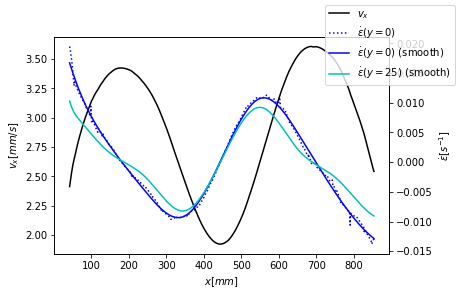

In [129]:
#####################
_fem_margin = 60
_fem_avrange = 2
_fem_ycut = int(20/_px_size)
_fem_ycutbig = int(30/_px_size)
#####################

print(fem_sigmaext.shape)
ctrpos = int(np.mean(ch_center)/_px_size)+45 #(fem_sigmaext.shape[0]-1)//2
fem_central_speed = fem_u[ctrpos,:,0]
fem_central_stress_raw = fem_sigmaext[ctrpos]
fem_central_stress_avg = np.mean(fem_sigmaext[ctrpos-_fem_avrange:ctrpos+_fem_avrange+1], axis=0)
fem_central_stress_up  = np.mean(fem_sigmaext[ctrpos-_fem_ycut-_fem_avrange:ctrpos-_fem_ycut+_fem_avrange+1], axis=0)
fem_central_stress_dwn = np.mean(fem_sigmaext[ctrpos+_fem_ycut-_fem_avrange:ctrpos+_fem_ycut+_fem_avrange+1], axis=0)
fem_central_stress_upup  = np.mean(fem_sigmaext[ctrpos-_fem_ycutbig-_fem_avrange:ctrpos-_fem_ycutbig+_fem_avrange+1], axis=0)
fem_central_stress_dwndwn = np.mean(fem_sigmaext[ctrpos+_fem_ycutbig-_fem_avrange:ctrpos+_fem_ycutbig+_fem_avrange+1], axis=0)
fem_central_stress = np.empty_like(fem_central_stress_raw)
for i in range(len(fem_central_stress)):
    xarr_idx = int(i*_px_size)
    ch_px = int(ch_center[xarr_idx]/_px_size)
    fem_central_stress[i] = np.mean(fem_sigmaext[ch_px-_fem_avrange:ch_px+_fem_avrange+1,i])
fem_stresscut_up = np.where(fem_x_px*_px_size<450, fem_central_stress_upup, fem_central_stress_up)
fem_stresscut_dwn = np.where(fem_x_px*_px_size<450, fem_central_stress_dwn, fem_central_stress_dwndwn)
fem_stresscut = 0.5*(fem_stresscut_up+fem_stresscut_dwn)

spl_stressctr = UnivariateSpline(fem_x_px[_fem_margin:-_fem_margin]*_px_size, fem_central_stress_avg[_fem_margin:-_fem_margin], 
                                 s=0.0003)
spl_stresscut = UnivariateSpline(fem_x_px[_fem_margin:-_fem_margin]*_px_size, fem_stresscut[_fem_margin:-_fem_margin], 
                                 s=0.0003)

fig, ax = plt.subplots()
fem_x_px = np.array(fem_x_px)
ax.plot(fem_x_px[_fem_margin:-_fem_margin]*_px_size, fem_central_speed[_fem_margin:-_fem_margin], 'k-', label=r'$v_x$')
ax.set_xlabel(r'$x [mm]$')
ax.set_ylabel(r'$v_x [mm/s]$')
ax2 = ax.twinx()
#ax2.plot(fem_x_px[_fem_margin:-_fem_margin]*_px_size, fem_central_stress_raw[_fem_margin:-_fem_margin], 'r:', 
#         label=r'$\dot\varepsilon_{raw}$')
ax2.plot(fem_x_px[_fem_margin:-_fem_margin]*_px_size, fem_central_stress_avg[_fem_margin:-_fem_margin], 'b:', 
         label=r'$\dot\varepsilon(y=0)$')
ax2.plot(fem_x_px[_fem_margin:-_fem_margin]*_px_size, spl_stressctr(fem_x_px[_fem_margin:-_fem_margin]*_px_size), 'b', 
         label=r'$\dot\varepsilon(y=0)$ (smooth)')
#ax2.plot(fem_x_px[_fem_margin:-_fem_margin]*_px_size, fem_stresscut[_fem_margin:-_fem_margin], 
#         'c:', label=r'$\dot\varepsilon(y=25)$')
ax2.plot(fem_x_px[_fem_margin:-_fem_margin]*_px_size, spl_stresscut(fem_x_px[_fem_margin:-_fem_margin]*_px_size), 
         'c', label=r'$\dot\varepsilon(y=25)$ (smooth)')
ax2.set_ylabel(r'$\dot\varepsilon [s^{-1}]$')
fig.legend()

np.savetxt(os.path.join(fout_fig1, 'FEM_sigmaext_cut.txt'), np.asarray([fem_x_px*_px_size, 
                        fem_central_stress_avg, spl_stressctr(fem_x_px*_px_size), 
                        fem_stresscut, spl_stresscut(fem_x_px*_px_size)]).T, 
          delimiter='\t', header='x[mm]\tsext(y=0)\tsext_smooth(y=0)\tsext(y=25)\tsext_smooth(y=25)')